In [16]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns, scipy.stats as stats, pandas as pd, os, glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.stats import rankdata
from scipy.stats import ttest_ind

In [17]:
df_clean = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
patients = df_clean['subj'].unique().tolist()
print(patients)
n_pts = len(patients)
df_clean

[9, 11, 12, 18, 21, 22]


,dir_flip,sess_flip,chosen_pos_aligned,div_pos_aligned,stim_pos_aligned,true_class,pred_class,err_type,invalid,incomplete,...,expName,psychopyVersion,frameRate,expStart,Unnamed: 119,chosen_pos,Unnamed: 112,stim_ranks,resp_ranks,block_name
0,1.0,0.0,-0.044,-0.0,0.02,1,0,-1,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.044,NaN,21.5,10.5,baseline_1.0
1,1.0,0.0,0.040,-0.0,0.38,1,1,0,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.040,NaN,39.5,27.0,baseline_1.0
2,0.0,0.0,-0.044,0.0,-0.02,0,0,0,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,-0.044,NaN,19.5,10.5,baseline_1.0
3,1.0,0.0,-0.068,-0.0,0.06,1,0,-1,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.068,NaN,23.5,8.0,baseline_1.0
4,0.0,0.0,0.008,0.0,0.38,1,1,0,False,False,...,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,0.008,NaN,39.5,20.0,baseline_1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,1.0,1.0,-0.296,-0.2,-0.22,0,0,0,False,False,...,asymmetry_final,2024.2.4,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.296,NaN,18.5,16.5,pen_comp_1.0
1436,0.0,1.0,0.160,-0.2,0.10,1,1,0,False,False,...,asymmetry_final,2024.2.4,60.0,2026-01-01 16h46.37.833115 -0700,NaN,-0.160,NaN,35.5,32.0,pen_comp_1.0
1437,0.0,1.0,-0.396,-0.2,-0.30,0,0,0,False,False,...,asymmetry_final,2024.2.4,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.396,NaN,10.5,3.5,pen_comp_1.0
1438,0.0,1.0,-0.344,-0.2,-0.38,0,0,0,False,False,...,asymmetry_final,2024.2.4,60.0,2026-01-01 16h46.37.833115 -0700,NaN,0.344,NaN,2.5,11.0,pen_comp_1.0


### timing checks

len(df): 240


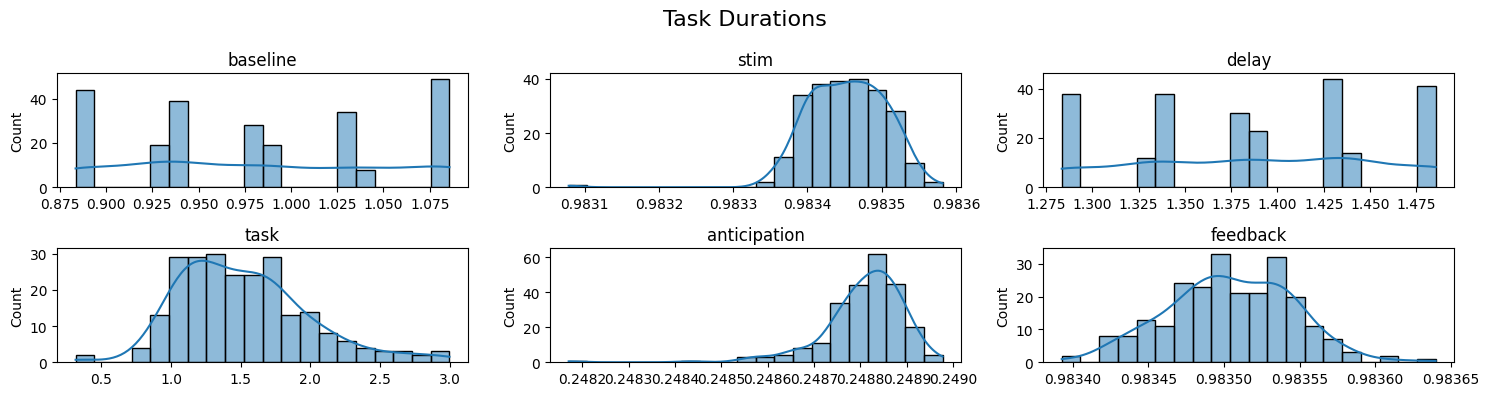

In [19]:
# choose what youre plotting
ptID = 9
df_analysis = df_clean[df_clean['subj'] == ptID].copy().reset_index(drop=True)
# df_analysis = df_clean.copy()
print(f'len(df): {len(df_analysis)}')

# create column for each phases's duration
expt_phases = ['baseline', 'stim', 'delay', 'task', 'anticipation', 'feedback']
for phase in expt_phases:
    df_analysis[f'{phase}_dur'] = df_analysis[f'{phase}.stopped'] - df_analysis[f'{phase}.started']

# sid, check if these are needed replacements
df_analysis['stim_dur'] = df_analysis['stim.stopped'] - df_analysis['target_stim.started']
df_analysis['feedback_dur'] = df_analysis['feedback.stopped'] - df_analysis['no_resp_text.started']

fig, axs = plt.subplots(2, 3, figsize=(15, 4))
axs, ax = axs.flatten(), 0

for expt_phase in expt_phases:

    sns.histplot(df_analysis[f'{expt_phase}_dur'], bins=20, kde=True, ax=axs[ax])
    axs[ax].set(title=expt_phase, xlabel='', ylabel='Count')
    ax += 1

plt.suptitle(f'Task Durations', fontsize=16)
plt.tight_layout()
plt.show()

### error trials

In [21]:
# choose what youre plotting
ptID = 9
df_analysis = df_clean[df_clean['subj'] == ptID].copy().reset_index(drop=True)
df_analysis = df_clean.copy()
print(f'len(df): {len(df_analysis)}')

num_incomplete = df_analysis['incomplete'].sum()
num_invalid = df_analysis['invalid'].sum()
num_incorrect = df_analysis['incorrect'].sum()
print(f'\
incomplete: {num_incomplete} ({num_incomplete / 240 * 100:.2f}%),\
 invalid: {num_invalid} ({num_invalid / 240 * 100:.2f}%),\
 incorrect: {num_incorrect} ({num_incorrect / 240 * 100:.2f}%)')

# proportion correct
prop_correct = df_analysis['correct'].mean()
print(f'Proportion correct: {prop_correct:.2f}')

# pearson and spearman correlations between stim_pos_aligned and chosen_pos_aligned
pearson_corr = df_analysis['stim_pos_aligned'].corr(df_analysis['chosen_pos_aligned'], method='pearson')
spearman_corr = df_analysis['stim_pos_aligned'].corr(df_analysis['chosen_pos_aligned'], method='spearman')
print(f'Pearson correlation: {pearson_corr:.2f}')
print(f'Spearman correlation: {spearman_corr:.2f}')

# ensure this is the same
pearson_corr = df_analysis['target_pos'].corr(df_analysis['chosen_pos'], method='pearson')
spearman_corr = df_analysis['target_pos'].corr(df_analysis['chosen_pos'], method='spearman')


len(df): 1440
incomplete: 36 (15.00%), invalid: 30 (12.50%), incorrect: 248 (103.33%)
Proportion correct: 0.79
Pearson correlation: 0.70
Spearman correlation: 0.71


### response profile

In [48]:
# fig, axs = plt.subplots(1, 3, figsize=(12, 3))
# axs, ax = axs.flatten(), 0

# # groupby condition
# for cond in ['pen_comp', 'baseline', 'rew_comp']: # ordered
    
#     df_cond = df_analysis[df_analysis['condition'] == cond]
    
#     axs[ax].hist(df_cond['chosen_pos_aligned'], bins=20, color='deepskyblue')
#     axs[ax].axvline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='--')
    
#     # true dist line depends on cond
#     if cond == 'baseline':
#         axs[ax].axhline(4*n_pts, color='black', linestyle='--', label='true dist')
#     elif cond == 'pen_comp':
#         axs[ax].hlines(8*n_pts, -.4, -.2, color='black', linestyle='--', label='true dist')
#         axs[ax].hlines(4*n_pts, -.2, .2, color='black', linestyle='--')
#     elif cond == 'rew_comp':
#         axs[ax].hlines(4*n_pts, -.2, .2, color='black', linestyle='--', label='true dist')
#         axs[ax].hlines(8*n_pts, .2, .4, color='black', linestyle='--')
            
#     axs[ax].set(title=f'{cond}', xlabel='response position', ylabel='count')
#     ax += 1

# plt.suptitle(f'Response distribution', y=1.05)
# plt.show()

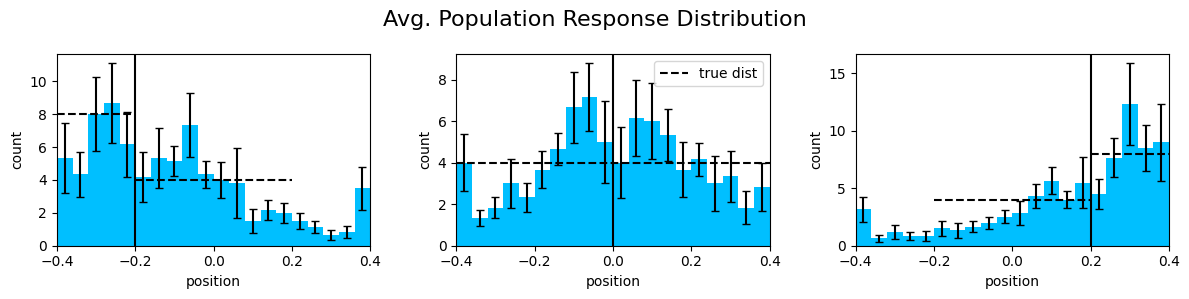

In [49]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs, ax = axs.flatten(), 0

for cond in ['pen_comp', 'baseline', 'rew_comp']: # ordered

    df_cond = df_analysis[df_analysis['condition'] == cond].copy()

    ### compute a histogram of responses per subj
    resp_cts = []
    for subj, subj_df in df_cond.groupby('subj'):
        counts, _ = np.histogram(subj_df['chosen_pos_aligned'], bins=20)
        resp_cts.append(counts)
    resp_cts = np.array(resp_cts)

    mean_resp_cts = resp_cts.mean(axis=0)
    sen_resp_cts = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])
    ###
    
    # plot
    axs[ax].bar(np.linspace(-.38,.38,20), mean_resp_cts, width=.04,
                color='deepskyblue', yerr=sen_resp_cts, capsize=3)

    axs[ax].set(xlabel='position', ylabel='count', xlim=(-.4, .4))

    # boundary
    axs[ax].axvline(df_cond['div_pos_aligned'].iloc[0], color='black', linestyle='-')

    # true dist lines
    if cond == 'baseline':
        axs[ax].axhline(4, color='black', linestyle='--', label='true dist')
    elif cond == 'pen_comp':
        axs[ax].hlines(8, -.4, -.2, color='black', linestyle='--', label='true dist')
        axs[ax].hlines(4, -.2, .2, color='black', linestyle='--')
    elif cond == 'rew_comp':
        axs[ax].hlines(4, -.2, .2, color='black', linestyle='--', label='true dist')
        axs[ax].hlines(8, .2, .4, color='black', linestyle='--')
 
    ax += 1

axs[1].legend()
plt.suptitle(f'Avg. Population Response Distribution', fontsize=16)
plt.tight_layout()
plt.show()
